# Day 1 — Starter / Answer Key
## Data Analyst Foundations | Pandas · Seaborn · Plotly · openpyxl

---

### How to use this file
- Read the comment block above each cell — that is your question
- Close this file, open a blank notebook and write the code yourself first
- Come back and compare your code with the answer here
- Focus on understanding WHY each line is written, not memorizing it

**Dataset:** Titanic — passenger survival data  
**Source:** https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

---

## STEP 1 — Import Libraries

In [2]:
# Import the 5 libraries we need today
# pandas for data manipulation
# numpy for numerical operations
# seaborn for static charts
# matplotlib.pyplot for displaying seaborn charts
# plotly.express for interactive charts
# Use standard aliases: pd, np, sns, plt, px

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

print('All libraries imported successfully!')

All libraries imported successfully!


## STEP 2 — Load the Dataset

In [3]:
# Load the Titanic CSV directly from this URL into a DataFrame called df
# Then display the first 5 rows to see what the data looks like
# URL: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## STEP 3 — Explore the Dataset

In [4]:
# How many rows and columns does this dataset have?

print('Shape:', df.shape)

Shape: (891, 12)


In [5]:
# Show all column names, their data types, and how many non-null values each column has
# This tells you which columns have missing data and what type each column is

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Show a statistical summary of all numeric columns
# You will see count, mean, std, min, 25%, 50%, 75%, max for every number column

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Count how many missing values exist in each column
# Age, Cabin and Embarked will show missing values

print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
# Check if there are any duplicate rows in the dataset

print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [9]:
# How many male and female passengers are there?
# Use value_counts on the Sex column

print(df['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


In [10]:
# How many passengers were in each ticket class?
# Pclass 1 = First class, 2 = Second class, 3 = Third class

print(df['Pclass'].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


## STEP 4 — Select and Filter Data

In [11]:
# Select only the Name and Age columns and show the first 5 rows

print(df[['Name', 'Age']].head())

                                                Name   Age
0                            Braund, Mr. Owen Harris  22.0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0
2                             Heikkinen, Miss. Laina  26.0
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0
4                           Allen, Mr. William Henry  35.0


In [12]:
# Filter the dataset to show only female passengers
# Then print how many female passengers there are

female_passengers = df[df['Sex'] == 'female']
print('Female passengers:', len(female_passengers))

Female passengers: 314


In [13]:
# Filter the dataset to show only passengers who survived
# Survived == 1 means survived, Survived == 0 means did not survive

survivors = df[df['Survived'] == 1]
print('Total survivors:', len(survivors))

Total survivors: 342


In [14]:
# Filter to show only female passengers who survived
# You need TWO conditions joined with & (AND operator)
# Each condition must be wrapped in its own parentheses

female_survivors = df[(df['Sex'] == 'female') & (df['Survived'] == 1)]
print('Female survivors:', len(female_survivors))

Female survivors: 233


In [15]:
# Filter to show only passengers older than 60 years

elderly = df[df['Age'] > 60]
print('Passengers older than 60:', len(elderly))

Passengers older than 60: 22


In [16]:
# Use iloc to select the first 3 rows and first 4 columns
# iloc uses integer index positions just like list slicing

print(df.iloc[0:3, 0:4])

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name  
0                            Braund, Mr. Owen Harris  
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  
2                             Heikkinen, Miss. Laina  


## STEP 5 — Clean the Data

In [17]:
# The Age column has around 177 missing values
# Fill those missing values with the mean age of all passengers
# We use mean because it is the most representative single value when no other info is available

df['Age'] = df['Age'].fillna(df['Age'].mean())
print('Missing Age values after fill:', df['Age'].isnull().sum())

Missing Age values after fill: 0


In [18]:
# The Embarked column has 2 missing values
# Fill missing Embarked with the most frequently occurring value
# mode() returns the most common value — use [0] to get it as a single value not a Series

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print('Missing Embarked values after fill:', df['Embarked'].isnull().sum())

Missing Embarked values after fill: 0


In [19]:
# The Cabin column has too many missing values (around 77%) to be useful
# Drop the entire Cabin column from the dataframe

df = df.drop(columns=['Cabin'])
print('Columns remaining:', df.columns.tolist())

Columns remaining: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [20]:
# Rename the column Pclass to PassengerClass for better readability

df = df.rename(columns={'Pclass': 'PassengerClass'})
print(df.columns.tolist())

['PassengerId', 'Survived', 'PassengerClass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [21]:
# Verify the dataset is fully clean now
# Check for any remaining missing values across all columns

print('Remaining missing values:')
print(df.isnull().sum())

Remaining missing values:
PassengerId       0
Survived          0
PassengerClass    0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Embarked          0
dtype: int64


## STEP 6 — Transform the Data

In [22]:
# Create a new column called AgeGroup that categorizes each passenger by age
# If Age < 18 then Child
# If Age is between 18 and 60 then Adult
# If Age > 60 then Senior
# Write a function and use apply to run it on every row of the Age column

def age_group(age):
    if age < 18:
        return 'Child'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Senior'

df['AgeGroup'] = df['Age'].apply(age_group)
print(df['AgeGroup'].value_counts())

AgeGroup
Adult     756
Child     113
Senior     22
Name: count, dtype: int64


In [23]:
# Sort the dataframe by Age from oldest to youngest
# Show the Name and Age columns of the top 5 oldest passengers

df_sorted = df.sort_values('Age', ascending=False)
print(df_sorted[['Name', 'Age']].head(5))

                                     Name   Age
630  Barkworth, Mr. Algernon Henry Wilson  80.0
851                   Svensson, Mr. Johan  74.0
96              Goldschmidt, Mr. George B  71.0
493               Artagaveytia, Mr. Ramon  71.0
116                  Connors, Mr. Patrick  70.5


## STEP 7 — Analyze with Groupby

In [24]:
# What is the survival rate for males vs females?
# Group by Sex and get the mean of the Survived column
# Mean of a 0 and 1 column gives you the proportion — that is the survival rate

survival_by_sex = df.groupby('Sex')['Survived'].mean()
print(survival_by_sex)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [25]:
# What is the average Age and Fare for each PassengerClass?
# Group by PassengerClass and get the mean of the Age and Fare columns together

class_stats = df.groupby('PassengerClass')[['Age', 'Fare']].mean()
print(class_stats)

                      Age       Fare
PassengerClass                      
1               37.048118  84.154687
2               29.866958  20.662183
3               26.403259  13.675550


In [26]:
# Group by both PassengerClass AND Sex at the same time
# Find the count and mean survival rate for each combination
# Call reset_index() at the end to get a flat clean DataFrame instead of a multi-index

group_result = df.groupby(['PassengerClass', 'Sex'])['Survived'].agg(['count', 'mean']).reset_index()
print(group_result)

   PassengerClass     Sex  count      mean
0               1  female     94  0.968085
1               1    male    122  0.368852
2               2  female     76  0.921053
3               2    male    108  0.157407
4               3  female    144  0.500000
5               3    male    347  0.135447


## STEP 8 — Visualize with Seaborn (Static Charts)

C:\Users\ADINATH\AppData\Local\Temp\ipykernel_9196\915134685.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette='Set2')


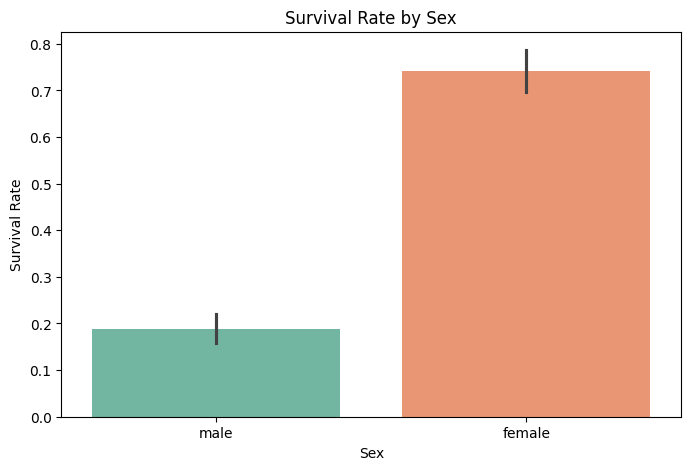

In [27]:
# Create a bar chart showing survival rate by Sex
# x axis = Sex, y axis = Survived, use palette Set2
# Add a title and a y axis label

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Sex', y='Survived', palette='Set2')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

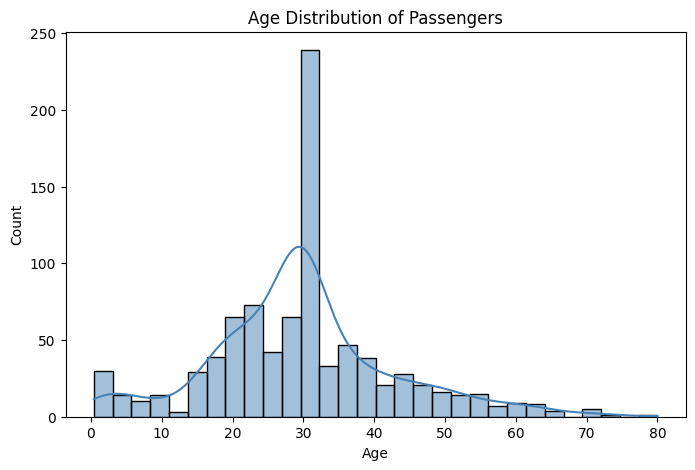

In [28]:
# Create a histogram showing the distribution of passenger Ages
# Use 30 bins and enable the KDE curve
# KDE is a smooth line that shows the shape of the distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Passengers')
plt.show()

C:\Users\ADINATH\AppData\Local\Temp\ipykernel_9196\3887804230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PassengerClass', y='Fare', palette='pastel')


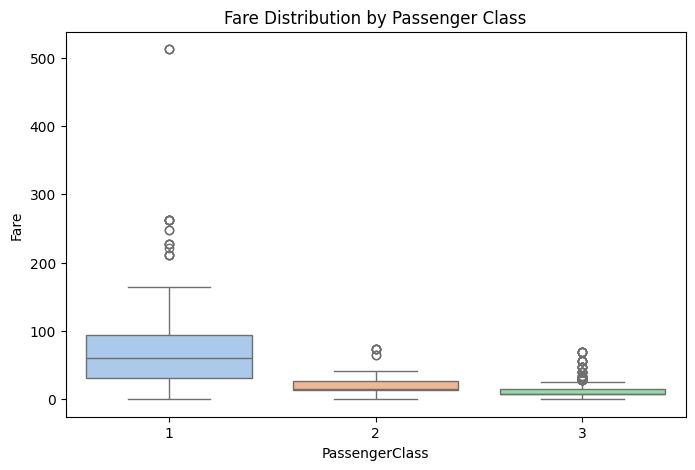

In [29]:
# Create a box plot showing Fare spread for each PassengerClass
# x axis = PassengerClass, y axis = Fare
# A box plot shows the median, interquartile range, and outliers all in one

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='PassengerClass', y='Fare', palette='pastel')
plt.title('Fare Distribution by Passenger Class')
plt.show()

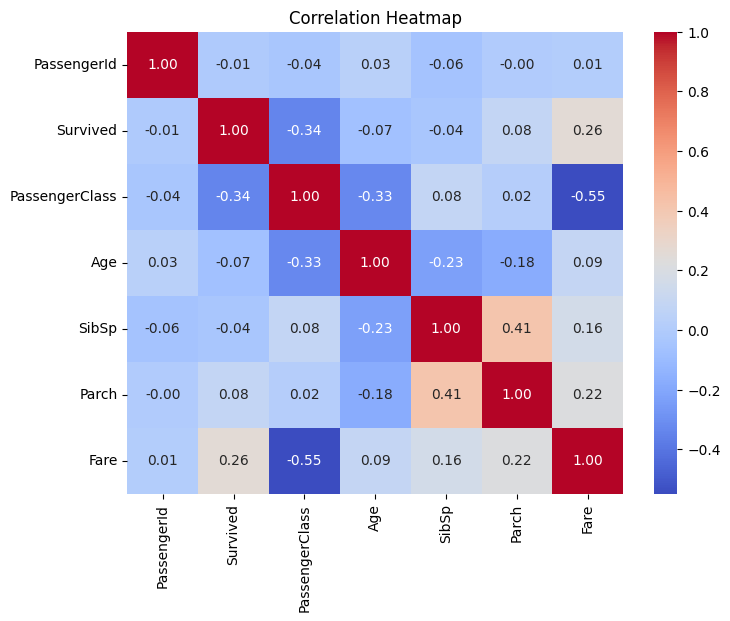

In [30]:
# Create a correlation heatmap for all numeric columns
# First select only numeric columns using select_dtypes
# Use annot=True to show the correlation number inside each box
# cmap coolwarm — red means strong positive, blue means strong negative correlation

plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## STEP 9 — Visualize with Plotly (Interactive Charts)

In [32]:
# Create an interactive bar chart showing passenger count per PassengerClass
# First get value_counts and reset_index to make it a clean DataFrame
# Color each bar by PassengerClass and hover to see exact counts
#pip install "nbformat>=4.2.0"

class_counts = df['PassengerClass'].value_counts().reset_index()
class_counts.columns = ['PassengerClass', 'Count']

fig = px.bar(class_counts, x='PassengerClass', y='Count',
             title='Passenger Count by Class',
             color='PassengerClass')

# import plotly.io as pio
# pio.renderers.default = "browser" # or "notebook_connected" 

fig.show()

In [33]:
# Create an interactive scatter plot of Age vs Fare
# Color the dots by the Survived column so we can visually spot survival patterns
# Add hover_data so hovering over a dot shows the passenger Name and Sex

fig = px.scatter(df, x='Age', y='Fare',
                 color='Survived',
                 hover_data=['Name', 'Sex'],
                 title='Age vs Fare — Colored by Survival')
fig.show()

In [34]:
# Create an interactive pie chart showing the survival split
# Map the 0 and 1 values to readable labels: Did Not Survive and Survived
# Use px.colors.qualitative.Set2 for the color scheme

survival_counts = df['Survived'].value_counts().reset_index()
survival_counts.columns = ['Survived', 'Count']
survival_counts['Survived'] = survival_counts['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})

fig = px.pie(survival_counts, values='Count', names='Survived',
             title='Survival Distribution',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.show()

## STEP 10 — Export the Cleaned Data

In [35]:
# Export the cleaned dataframe to a CSV file called titanic_cleaned.csv
# Set index=False so the row numbers are not saved as an extra column in the file

df.to_csv('titanic_cleaned.csv', index=False)
print('Cleaned data exported to titanic_cleaned.csv')

Cleaned data exported to titanic_cleaned.csv


In [36]:
# Export to an Excel file called titanic_report.xlsx with two separate sheets
# Sheet 1 named FullData contains the complete cleaned dataframe
# Sheet 2 named Survivors contains only the rows where Survived equals 1
# Use pd.ExcelWriter inside a with block to write multiple sheets at once

with pd.ExcelWriter('titanic_report.xlsx') as writer:
    df.to_excel(writer, sheet_name='FullData', index=False)
    df[df['Survived'] == 1].to_excel(writer, sheet_name='Survivors', index=False)

print('Excel report exported with 2 sheets!')

Excel report exported with 2 sheets!


---

## Compare Your Code Against This

When comparing ask yourself:
- Did you get the same output?
- Did you use a different method? Both can be valid
- Do you understand WHY each step was done?
- Is your code clean and readable?

Now open `task.md` for the extra challenges before pushing to GitHub.

**Commit message to use:**
```
Day 1 — starter complete | pandas EDA, seaborn, plotly, titanic dataset
```